In [5]:
import torch
import os
import skimage
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare sample data

In [9]:
dir = '/scr/yren/all_data_micronuclei_no_rescale/'
df = pd.read_csv(dir + 'metadata.csv')
screen = df[df.datasets == 'screen']
screen

,filenames,datasets,magnification,micron,split
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype.tif,screen,14,4.25,train
8,C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype.tif,screen,14,4.25,test
9,C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype.tif,screen,14,4.25,validation
15,C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype.tif,screen,14,4.25,validation
16,C2-20X_c0-DAPI-GFP_B1_Tile-8.phenotype.tif,screen,14,4.25,train
17,C2-20X_c0-DAPI-GFP_A3_Tile-6.phenotype.tif,screen,14,4.25,train
18,C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype.tif,screen,14,4.25,train
23,C2-20X_c0-DAPI-GFP_B3_Tile-10.phenotype.tif,screen,14,4.25,train


In [34]:
df[df.datasets.isin(['HeLa', 'RPE1'])]

,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5,train
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5,validation
2,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5,test
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5,train
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5,validation
5,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.5,test


In [35]:
screen.iloc[0]

filenames        C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype.tif
datasets                                              screen
magnification                                             14
micron                                                  4.25
split                                                  train
Name: 7, dtype: object

(2960, 2960)


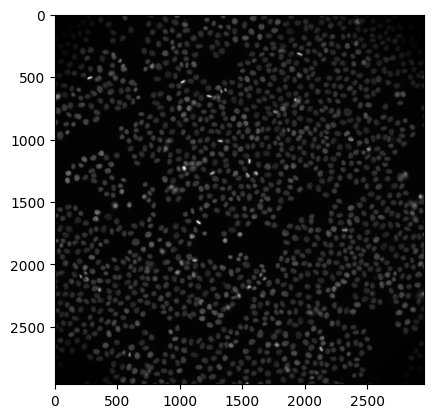

In [36]:
im = skimage.io.imread(f'{dir}{screen.iloc[0].split}/{screen.iloc[0].filenames}')
print(im.shape)
plt.imshow(im, cmap='gray')
plt.show()

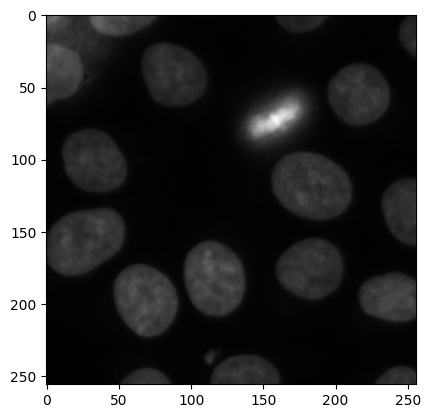

In [37]:
R = 1200
C = 1100
P = 256
crop = im[R:R+P, C:C+P]
plt.imshow(crop, cmap='gray')
plt.show()

In [6]:
def patch_to_rgb(patch, edges=False):
    if edges:
        sobel = skimage.filters.sobel(patch)
        sobel = 2*skimage.exposure.rescale_intensity(sobel, out_range=np.float32)
        sobel[sobel > 1.] = 1.
    else:
        sobel = patch
        
    px = np.concatenate(
        (sobel[np.newaxis,:,:], patch[np.newaxis,:,:], patch[np.newaxis,:,:]), 
        axis=0)
    return torch.Tensor(px)

In [39]:
x = patch_to_rgb(crop, edges=False)
x = x.unsqueeze(0) # add batch information
print(x.shape)

torch.Size([1, 3, 256, 256])


torch.Size([1, 3, 448, 448])
torch.Size([448, 448, 3])


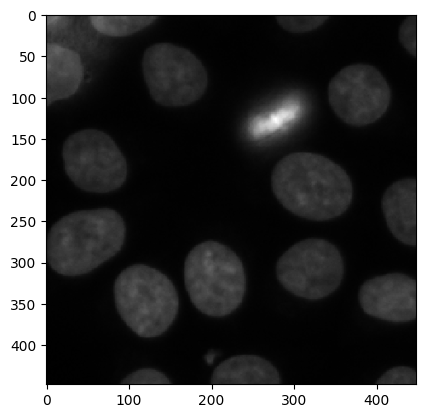

In [40]:
x = torch.nn.functional.interpolate(x, (448,448))
print(x.shape)
# 3,448,448
print(x.squeeze(0).permute(1,2,0).shape)
plt.imshow(x.squeeze(0).permute(1,2,0)[:,:,2], cmap='gray')
plt.show()

# Extract features from Dinov2

In [41]:
device = 'cuda:3'
feature_extractor = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to(device) # dinov2 vit small model
x = x.to(device)
output_list = feature_extractor.forward_features(x)
x = feature_extractor.forward_features(x)['x_norm_patchtokens']

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main


In [42]:
print(output_list.keys())

dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


In [43]:
print(output_list['x_norm_clstoken'].shape)
print(output_list['x_norm_regtokens'].shape)
print(output_list['x_norm_patchtokens'].shape)
print(output_list['x_prenorm'].shape)
print(output_list['masks']) # refer to paper, randomly masked out (ignore) some tokens

torch.Size([1, 384])
torch.Size([1, 4, 384])
torch.Size([1, 1024, 384])
torch.Size([1, 1029, 384])
None


In [44]:
B,T,C = x.shape # Batch, Token size * Toekn size, Channel
H,W = 32,32
x = x.reshape(B,H,W,C).permute(0,3,1,2)
print(x.shape)

torch.Size([1, 384, 32, 32])


In [45]:
print(B,T,C)

1 1024 384


(32, 32)


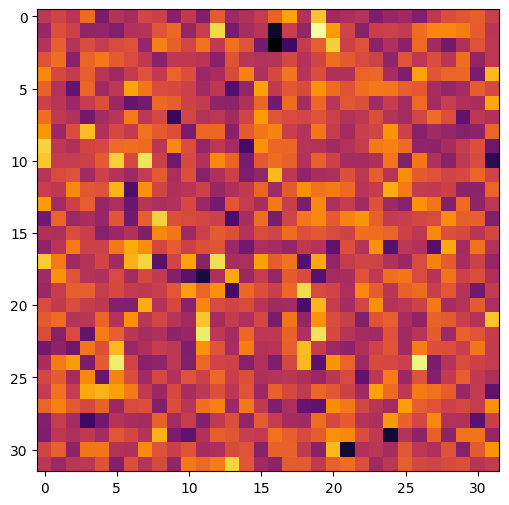

In [53]:
attn_head_1 = x.squeeze(0)[0].detach().cpu().numpy()
print(attn_head_1.shape)
# Plot it
plt.figure(figsize=(6,6))
plt.imshow(attn_head_1, cmap='inferno')

# Replicate the Arch in Mask2Former

In [87]:
import torch
import os
import skimage
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F

## masked attention & cross attention from Mask2Former

In [13]:
f'{dir}{screen.iloc[0].split}/{screen.iloc[0].filenames}'

'/scr/yren/all_data_micronuclei_no_rescale/train/C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype.tif'

In [3]:
dir = '/scr/yren/all_data_micronuclei_no_rescale/'
df = pd.read_csv(dir + 'metadata.csv')
screen = df[df.datasets == 'screen']
im = skimage.io.imread(f'{dir}{screen.iloc[0].split}/{screen.iloc[0].filenames}')

In [120]:
class DetectionModel(torch.nn.Module):
    
    def __init__(self, device, stride=8, finetune=False):
        super(DetectionModel, self).__init__()
        
        self.finetune = finetune
        
        # pretrained backbone has patch size 14 x 14, split into 14 row and columns
        self.feature_extractor = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to(device) # dinov2 vit small model

        def conv_block(in_channels, out_channels, kernel_size=(3,3), padding=(1,1), norm_shape=[96, 128, 128]):
            return torch.nn.Sequential(
                torch.nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
                torch.nn.LayerNorm(norm_shape),
                torch.nn.ReLU()
            )
            
        self.upscale1 = torch.nn.ConvTranspose2d(in_channels=384, out_channels=192, kernel_size=(2,2), stride=2)
        self.upscale1.to(device)
        self.block1 = conv_block(in_channels=192, out_channels=192, kernel_size=(3,3), padding=(1,1), norm_shape=[192, 64, 64])
        self.block2 = conv_block(in_channels=192, out_channels=192, kernel_size=(3,3), padding=(1,1), norm_shape=[192, 64, 64])
        self.block3 = conv_block(in_channels=192, out_channels=192, kernel_size=(3,3), padding=(1,1), norm_shape=[192, 64, 64])
        
        self.block1.to(device)
        self.block2.to(device)
        self.block3.to(device)
        
        # here number of features (d_model) represents channels
        self.decoder_layer1 = torch.nn.TransformerDecoderLayer(d_model=192, nhead=8, activation='relu', batch_first=True)  # Assuming d_model is 192
        self.transformer_decoder1 = torch.nn.TransformerDecoder(self.decoder_layer1, num_layers=4)
        self.transformer_decoder1.to(device)
        
        self.projection1 = torch.nn.Linear(384, 192)
        self.projection1.to(device)
        
        self.upscale2 = torch.nn.ConvTranspose2d(in_channels=192, out_channels=96, kernel_size=(2,2), stride=2)
        self.upscale2.to(device)
        self.block4 = conv_block(in_channels=96, out_channels=96, kernel_size=(3,3), padding=(1,1), norm_shape=[96, 128, 128])
        self.block5 = conv_block(in_channels=96, out_channels=96, kernel_size=(3,3), padding=(1,1), norm_shape=[96, 128, 128])
        self.block6 = conv_block(in_channels=96, out_channels=96, kernel_size=(3,3), padding=(1,1), norm_shape=[96, 128, 128])
        
        self.block4.to(device)
        self.block5.to(device)
        self.block6.to(device)
        
        self.projection2 = torch.nn.Linear(192, 96)
        self.projection2.to(device)
        
        # classification layer
        self.classifier = torch.nn.Conv2d(in_channels=96, out_channels=2, kernel_size=(1,1))
        self.classifier.to(device)
    
    def forward(self, x):
        with torch.no_grad():
            x = torch.nn.functional.interpolate(x, (448,448))
            x = self.feature_extractor.forward_features(x)['x_norm_patchtokens']
        B,T,C = x.shape # Batch, Token size * Toekn size, Channel
        W,H = 32,32
        memory = x # original image features
        print(memory.shape)
        x = x.reshape(B,W,H,C).permute(0,3,1,2)
        # 1,384,32,32
        print(x.shape)
        
        # Pixel Decoder Block 1
        x = self.upscale1(x)
        residual1 = x
        x = self.block1(x)
        residual2 = x
        x = self.block2(x) + residual1
        x = self.block3(x) + residual2
        # x: 1,192,64,64
        
        # Transformer Decoder Block 1
        B,C,H,W = x.shape
        target = x.reshape(B,H*W,C)
        memory = self.projection1(memory)
        transformer_x = self.transformer_decoder1(tgt=target, memory=memory)
        # 1,4096,192 --> 1,192,64,64
        
        # Pixel Decoder Block 2
        x = self.upscale2(x)
        residual3 = x
        x = self.block4(x)
        residual4 = x
        x = self.block5(x) + residual3
        x = self.block6(x) + residual4
        # x: 1,96,128,128
        
        print(f'transformer x shape before: {transformer_x.shape}')
        transformer_x = self.projection2(transformer_x)
        print(f'transformer x shape after Linear: {transformer_x.shape}')
        print(B,C,H,W)
        transformer_x = transformer_x.reshape(B,96,H,W)
        print(transformer_x.shape)
        transformer_x = F.interpolate(x, (128,128))
        print(f'transformer x shape before: {transformer_x.shape}')
        
        # Sum up information
        print(f'x shape before summation: {x.shape}')
        print(f'transformer x shape before summation: {transformer_x.shape}')
        x = x + transformer_x
        
        # Classifier
        x = self.classifier(x)
        
        return x


In [121]:
R = 1200
C = 1100
P = 256
crop = im[R:R+P, C:C+P]
crop = patch_to_rgb(crop)
crop = crop.unsqueeze(0)
print(crop.shape)
device = 'cuda:3'
model = DetectionModel(device=device)

torch.Size([1, 3, 256, 256])


Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main


In [122]:
crop = crop.to(device)
output = model(crop)

torch.Size([1, 1024, 384])
torch.Size([1, 384, 32, 32])
transformer x shape before: torch.Size([1, 4096, 192])
transformer x shape after Linear: torch.Size([1, 4096, 96])
1 192 64 64
torch.Size([1, 96, 64, 64])
transformer x shape before: torch.Size([1, 96, 128, 128])
x shape before summation: torch.Size([1, 96, 128, 128])
transformer x shape before summation: torch.Size([1, 96, 128, 128])


In [116]:
print(output.shape)

torch.Size([1, 2, 128, 128])


In [77]:
output[0,0,:,:]

tensor([[-0.0207,  0.4243,  0.0763,  ..., -0.0179,  0.0720,  0.4300],
        [-0.5314,  1.8102, -1.1944,  ...,  1.2054, -0.1478,  0.1885],
        [-0.0395, -0.9065,  0.4986,  ...,  0.2290, -0.2451, -0.0291],
        ...,
        [-0.9027,  0.6611, -1.1664,  ...,  1.2874, -0.8250, -0.3766],
        [-0.3541,  0.3945, -0.3307,  ...,  0.3975, -0.7630, -0.2130],
        [-0.3507,  1.0470, -0.7185,  ...,  0.8517, -0.6918,  0.8115]],
       device='cuda:3', grad_fn=<SliceBackward0>)

# Load pretrained segmentation model (Mask2Former) from Dinov2

In [1]:
import torch
import os
import skimage
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation, Mask2FormerModel, Mask2FormerConfig

## Get decoder from mask2former

In [6]:
model = Mask2FormerModel.from_pretrained("facebook/mask2former-swin-small-coco-instance")

In [9]:

dir = '/scr/yren/all_data_micronuclei_no_rescale/'
df = pd.read_csv(dir + 'metadata.csv')
screen = df[df.datasets == 'screen']
im = skimage.io.imread(f'{dir}{screen.iloc[0].split}/{screen.iloc[0].filenames}')
R = 1200
C = 1100
P = 256
crop = im[R:R+P, C:C+P]
def patch_to_rgb(patch, edges=False):
    if edges:
        sobel = skimage.filters.sobel(patch)
        sobel = 2*skimage.exposure.rescale_intensity(sobel, out_range=np.float32)
        sobel[sobel > 1.] = 1.
    else:
        sobel = patch
        
    px = np.concatenate(
        (sobel[np.newaxis,:,:], patch[np.newaxis,:,:], patch[np.newaxis,:,:]), 
        axis=0)
    return torch.Tensor(px)
x = patch_to_rgb(crop, edges=False)
x = x.unsqueeze(0)
x = torch.nn.functional.interpolate(x, (448,448))

device = 'cuda:3'
feature_extractor = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to(device) # dinov2 vit small model
x = x.to(device)
output_list = feature_extractor.forward_features(x)
x = feature_extractor.forward_features(x)['x_norm_patchtokens']
encoder_outputs = x
print(x.shape)

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


torch.Size([1, 1024, 384])


In [140]:
print(x.shape)
projection_layer = torch.nn.Linear(384, 768).to(device)
x = projection_layer(x)  # Now shape is [1, 1024, 256]
print(x.shape)
x = x.to(device)

torch.Size([1, 1024, 384])
torch.Size([1, 1024, 768])


In [10]:
pix_dec = model.pixel_level_module.decoder.to(device)

In [15]:
pix_dec

Mask2FormerPixelDecoder(
  (position_embedding): Mask2FormerSinePositionEmbedding()
  (input_projections): ModuleList(
    (0): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
    )
    (1): Sequential(
      (0): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
    )
    (2): Sequential(
      (0): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
    )
  )
  (encoder): Mask2FormerPixelDecoderEncoderOnly(
    (layers): ModuleList(
      (0-5): 6 x Mask2FormerPixelDecoderEncoderLayer(
        (self_attn): Mask2FormerPixelDecoderEncoderMultiscaleDeformableAttention(
          (sampling_offsets): Linear(in_features=256, out_features=192, bias=True)
          (attention_weights): Linear(in_features=256, out_features=96, bias=True)
          (value_proj): Linear(in_features=256, out_features=256, bi

In [13]:
pix_dec.feature_channels

[96, 192, 384, 768]

In [14]:
pix_dec

<bound method Module.parameters of Mask2FormerPixelDecoder(
  (position_embedding): Mask2FormerSinePositionEmbedding()
  (input_projections): ModuleList(
    (0): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
    )
    (1): Sequential(
      (0): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
    )
    (2): Sequential(
      (0): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
    )
  )
  (encoder): Mask2FormerPixelDecoderEncoderOnly(
    (layers): ModuleList(
      (0-5): 6 x Mask2FormerPixelDecoderEncoderLayer(
        (self_attn): Mask2FormerPixelDecoderEncoderMultiscaleDeformableAttention(
          (sampling_offsets): Linear(in_features=256, out_features=192, bias=True)
          (attention_weights): Linear(in_features=256, out_features=96, bias=True)
          (value_proj): Linear(in

In [142]:
B,T,C = x.shape
x = x.reshape(B,C,32,32)
print(x.shape)
pix_dec(features=[x], encoder_outputs=encoder_outputs, output_attentions=256, output_hidden_states=192, return_dict=True)

torch.Size([1, 768, 32, 32])


AttributeError: 'Tensor' object has no attribute 'last_hidden_state'

In [108]:
help(pix_dec)

Help on Mask2FormerPixelDecoder in module transformers.models.mask2former.modeling_mask2former object:

class Mask2FormerPixelDecoder(torch.nn.modules.module.Module)
 |  Mask2FormerPixelDecoder(config: transformers.models.mask2former.configuration_mask2former.Mask2FormerConfig, feature_channels)
 |
 |  # Modified from from transformers.models.detr.modeling_deformable_detr.DeformableDetrModel with DeformableDetrModel->Mask2FormerPixelDecoder
 |
 |  Method resolution order:
 |      Mask2FormerPixelDecoder
 |      torch.nn.modules.module.Module
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, config: transformers.models.mask2former.configuration_mask2former.Mask2FormerConfig, feature_channels)
 |      Initialize internal Module state, shared by both nn.Module and ScriptModule.
 |
 |  forward(self, features, encoder_outputs=None, output_attentions=None, output_hidden_states=None, return_dict=None)
 |      Define the computation performed at every call.
 |
 |      

In [16]:
dec = model.transformer_module.decoder.to(device)
# dec(x)

In [106]:
help(dec)

Help on Mask2FormerMaskedAttentionDecoder in module transformers.models.mask2former.modeling_mask2former object:

class Mask2FormerMaskedAttentionDecoder(torch.nn.modules.module.Module)
 |  Mask2FormerMaskedAttentionDecoder(config: transformers.models.mask2former.configuration_mask2former.Mask2FormerConfig)
 |
 |  Transformer decoder consisting of *config.decoder_layers* layers. Each layer is a
 |  [`Mask2FormerMaskedAttentionDecoderLayer`]. The decoder updates the query embeddings through multiple cross
 |  (masked) and self-attention layers. The decoder uses a new **masked attention** mechanism instead of the standard
 |  cross-attention, which extracts localized features by constraining cross-attention to within the foreground region
 |  of the predicted mask for each query, instead of attending to the full feature map.
 |
 |  Args:
 |      config (`Mask2FormerConfig`):
 |          Configuration used to instantiate Mask2FormerMaskedAttentionDecoder.
 |
 |  Method resolution order:
 

In [17]:
dec

Mask2FormerMaskedAttentionDecoder(
  (layers): ModuleList(
    (0-8): 9 x Mask2FormerMaskedAttentionDecoderLayer(
      (self_attn): Mask2FormerAttention(
        (k_proj): Linear(in_features=256, out_features=256, bias=True)
        (v_proj): Linear(in_features=256, out_features=256, bias=True)
        (q_proj): Linear(in_features=256, out_features=256, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (activation_fn): ReLU()
      (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (cross_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (cross_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=256, out_features=2048, bias=True)
      (fc2): Linear(in_features=2048, out_features=256, bias=True)
      (final_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affin

In [33]:
im = skimage.io.imread(f'{dir}{screen.iloc[0].split}/{screen.iloc[0].filenames}')
print(im.shape)
R = 1200
C = 1100
P = 256
crop = im[R:R+P, C:C+P]

x = patch_to_rgb(crop, edges=False)
x = x.unsqueeze(0)
print(x.shape)

(2960, 2960)
torch.Size([1, 3, 256, 256])


In [14]:
with torch.no_grad():
    outputs = model(x)

In [17]:
class_queries_logits = outputs.class_queries_logits
masks_queries_logits = outputs.masks_queries_logits

In [25]:
masks = masks_queries_logits
print(masks.shape)

torch.Size([1, 100, 64, 64])


In [34]:
np.unique(class_queries_logits)

array([-7.56765  , -7.5644407, -7.510739 , ...,  6.7082005,  6.7140007,
        6.8230853], dtype=float32)

In [33]:
np.unique(masks)

array([-95.841324, -90.678185, -90.07705 , ...,  31.731113,  31.974506,
        32.80784 ], dtype=float32)

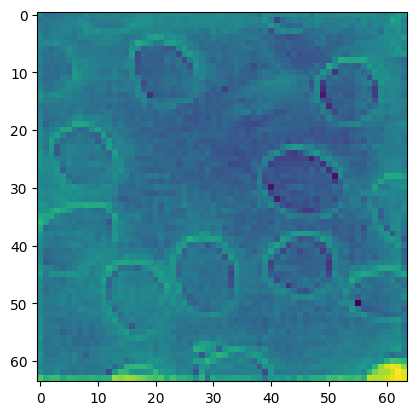

In [31]:
masks_mean = torch.mean(masks.squeeze(0), axis=0)
plt.imshow(masks_mean)

In [48]:
masks_mean.unsqueeze(0).unsqueeze(0).shape

torch.Size([1, 1, 64, 64])

torch.Size([1, 1, 256, 256])


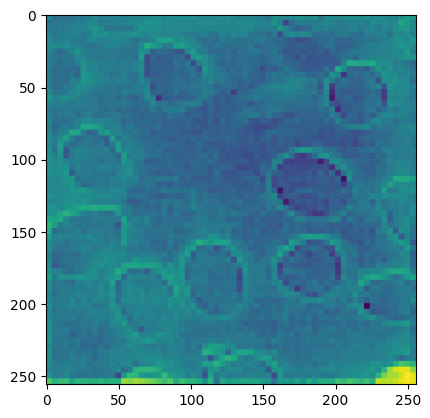

In [50]:
masks2 = torch.nn.functional.interpolate(masks_mean.unsqueeze(0).unsqueeze(0), (256, 256))
print(masks2.shape)
plt.imshow(masks2.squeeze(0).squeeze(0))

In [46]:
pred_instance_map = image_processor.post_process_instance_segmentation(
    outputs, target_sizes=[(P, P)]
)[0]
print(pred_instance_map['segmentation'].shape)

torch.Size([256, 256])
